In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 로컬 경로에서 데이터 불러오기
df = pd.read_csv(r'C:\Users\user\BDA_Data\Dataset\crime.csv')

# 데이터 정보 확인
df.info()

# 'REPORTED_DATE'를 datetime 형식으로 변환
df['REPORTED_DATE'] = pd.to_datetime(df['REPORTED_DATE'])

# 'REPORTED_DATE'를 인덱스로 설정하여 시계열 데이터로 변환
df = df.set_index('REPORTED_DATE')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460911 entries, 0 to 460910
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           460911 non-null  int64  
 1   OFFENSE_TYPE_ID      460911 non-null  object 
 2   OFFENSE_CATEGORY_ID  460911 non-null  object 
 3   REPORTED_DATE        460911 non-null  object 
 4   GEO_LON              457296 non-null  float64
 5   GEO_LAT              457296 non-null  float64
 6   NEIGHBORHOOD_ID      460911 non-null  object 
 7   IS_CRIME             460911 non-null  int64  
 8   IS_TRAFFIC           460911 non-null  int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 31.6+ MB


In [25]:
# 범죄 발생률 분석 - IS_CRIME (전체)
total_crimes = df['IS_CRIME'].sum()
print(f"총 범죄 건수: {total_crimes}")

총 범죄 건수: 335851


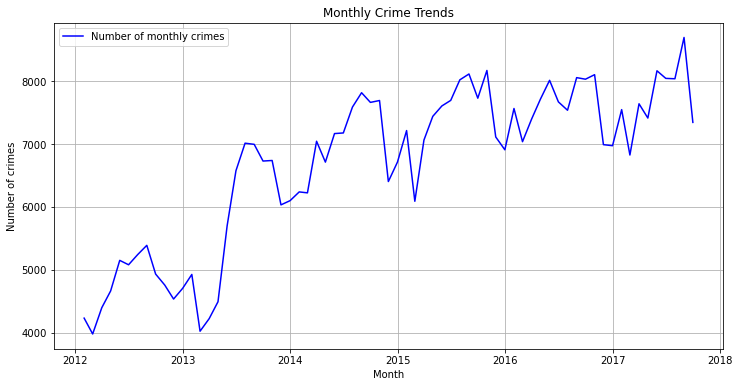

In [32]:
# 1. 월별 범죄 건수 분석
monthly_crime = df['IS_CRIME'].resample('M').size()
plt.figure(figsize=(12, 6))
plt.plot(monthly_crime, label='Number of monthly crimes', color='blue')
plt.title('Monthly Crime Trends')
plt.xlabel('Month')
plt.ylabel('Number of crimes')
plt.legend()
plt.grid(True)
plt.show()

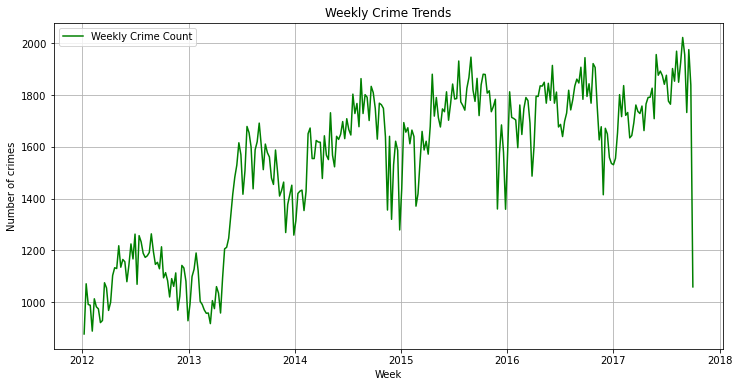

In [33]:
# 2. 주별 범죄 건수 분석
weekly_crime = df['IS_CRIME'].resample('W').size()
plt.figure(figsize=(12, 6))
plt.plot(weekly_crime, label='Weekly Crime Count', color='green')
plt.title('Weekly Crime Trends')
plt.xlabel('Week')
plt.ylabel('Number of crimes')
plt.legend()
plt.grid(True)
plt.show()

Most Frequent Crime Types:
traffic-accident                87420
traffic-accident-hit-and-run    33514
theft-items-from-vehicle        27468
traf-other                      25793
theft-of-motor-vehicle          23004
Name: OFFENSE_TYPE_ID, dtype: int64


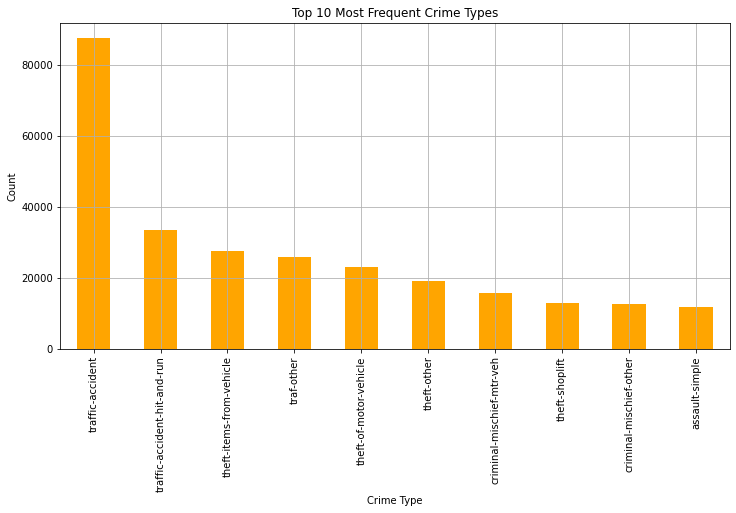

In [34]:
# 3. 가장 빈번한 범죄 유형 분석
most_frequent_types = df['OFFENSE_TYPE_ID'].value_counts()
print("Most Frequent Crime Types:")
print(most_frequent_types.head())

plt.figure(figsize=(12, 6))
most_frequent_types.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Most Frequent Crime Types')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [35]:
# Ensure 'REPORTED_DATE' is in datetime format and set as the index
df_1['REPORTED_DATE'] = pd.to_datetime(df_1['REPORTED_DATE'])
df_1 = df_1.set_index('REPORTED_DATE')

# Weekly crime count analysis
weekly_crime = df_1['IS_CRIME'].resample('W').size()

# Weekly crime count visualization
plt.figure(figsize=(12, 6))
plt.plot(weekly_crime, label='Weekly Crime Count', color='blue')
plt.title('Weekly Crime Trend')
plt.xlabel('Week')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.show()

KeyError: "None of ['REPORTED_DATE'] are in the columns"

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 48276 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 51396 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 50976 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 54805 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 48324 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 50900 missing from c

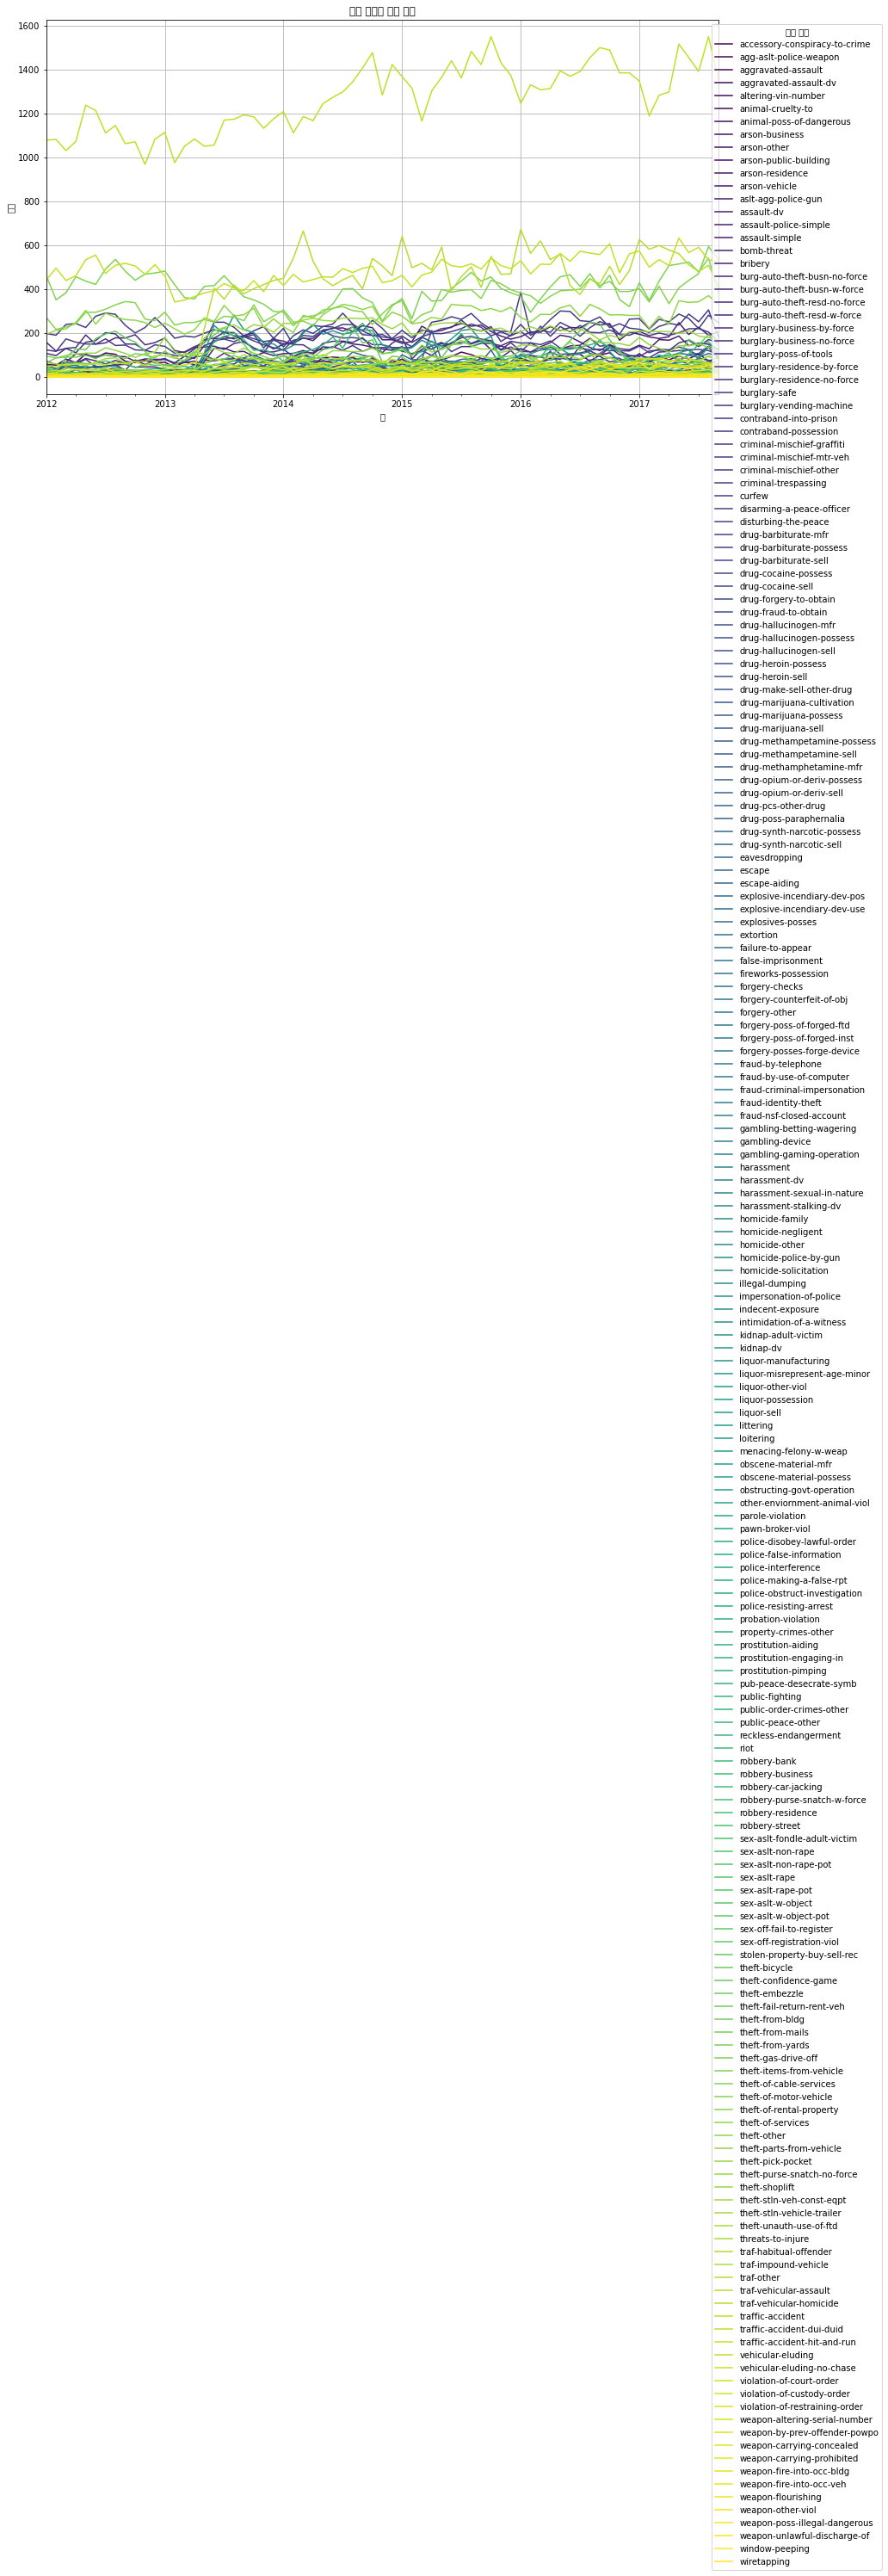

In [29]:
# 4. 월별 범죄 유형별 발생 추세
monthly_crime_by_type = df.groupby([df.index.to_period('M'), 'OFFENSE_TYPE_ID'])['IS_CRIME'].size().unstack().fillna(0)
monthly_crime_by_type.plot(figsize=(14, 8), colormap='viridis')
plt.title('범죄 유형별 월별 추세')
plt.xlabel('월')
plt.ylabel('건수')
plt.legend(title='범죄 유형', loc='upper right', bbox_to_anchor=(1.25, 1))
plt.grid(True)
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 48276 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 51396 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 50976 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 54805 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 48324 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 51452 missing from c

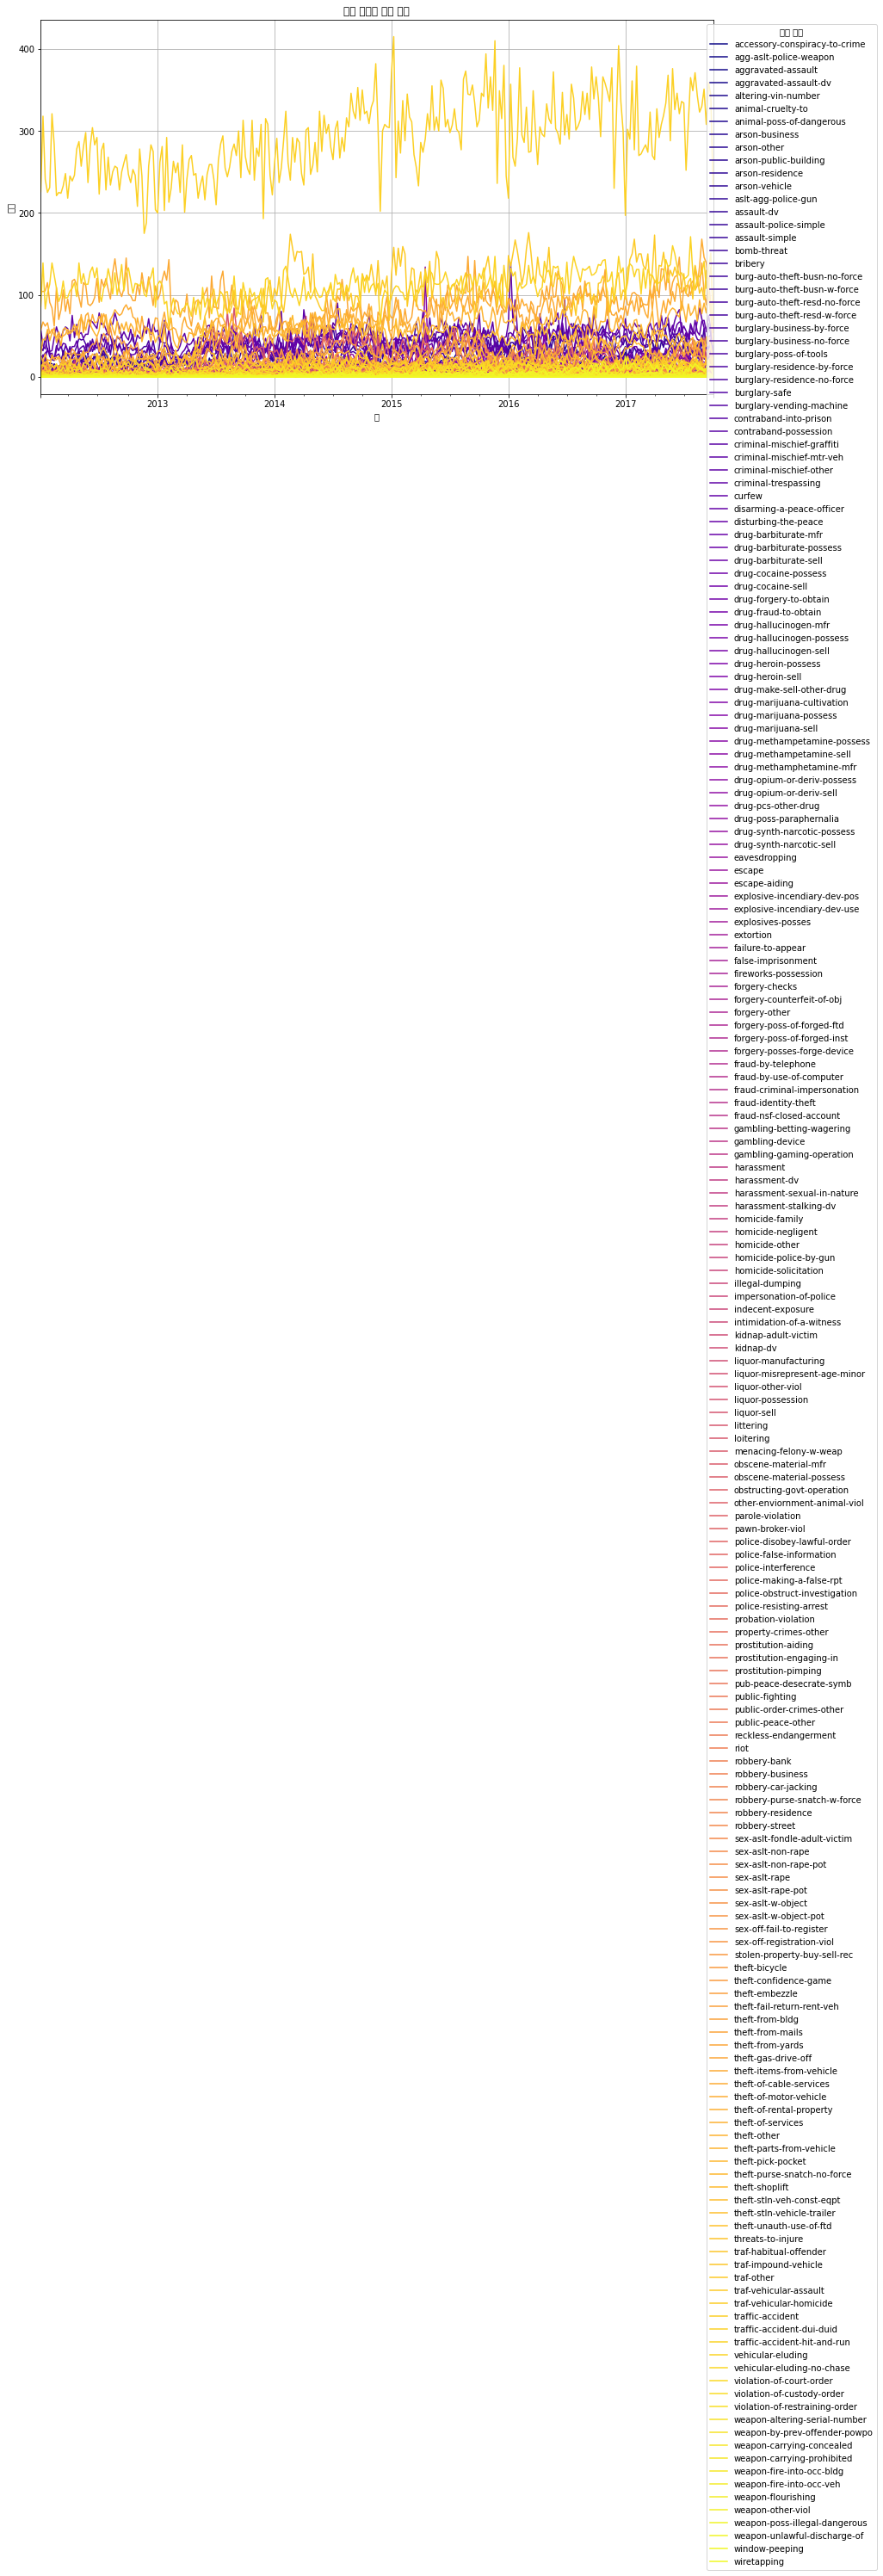

In [30]:
# 5. 주별 범죄 유형별 발생 추세
weekly_crime_by_type = df.groupby([df.index.to_period('W'), 'OFFENSE_TYPE_ID'])['IS_CRIME'].size().unstack().fillna(0)
weekly_crime_by_type.plot(figsize=(14, 8), colormap='plasma')
plt.title('범죄 유형별 주별 추세')
plt.xlabel('주')
plt.ylabel('건수')
plt.legend(title='범죄 유형', loc='upper right', bbox_to_anchor=(1.25, 1))
plt.grid(True)
plt.show()

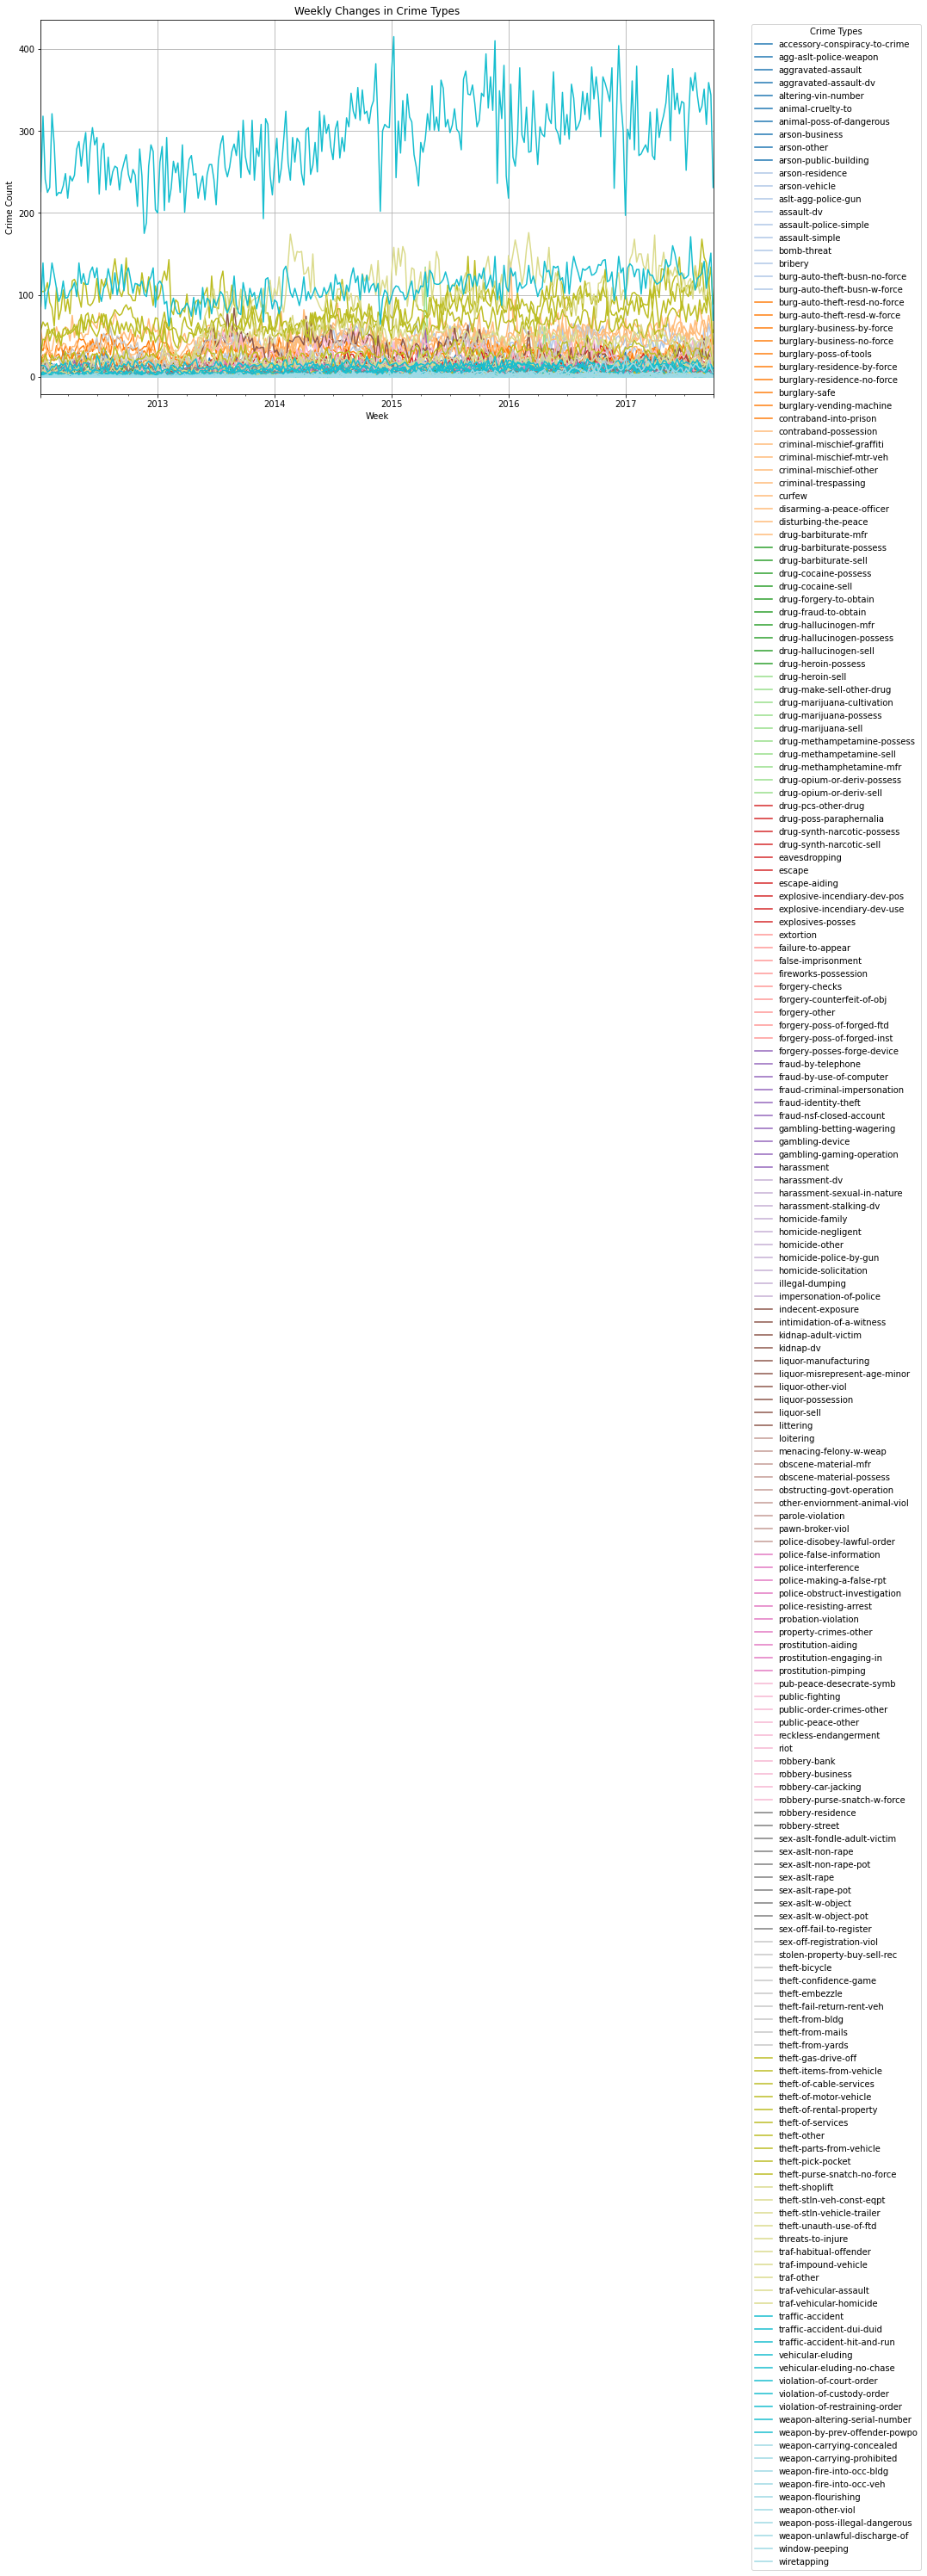

In [37]:
# 사건 유형별 주별 변화 추이
type_weekly_trend = df.groupby([df.index.to_period('W'), 'OFFENSE_TYPE_ID'])['IS_CRIME'].size().unstack(fill_value=0)

# 데이터 시각화
plt.figure(figsize=(14, 8))
type_weekly_trend.plot(ax=plt.gca(), colormap='tab20', legend=False)
plt.title('Weekly Changes in Crime Types')
plt.xlabel('Week')
plt.ylabel('Crime Count')
plt.legend(title='Crime Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()